In [1]:
import pandas as pd

In [2]:
orders = pd.read_csv('../data/processed/orders_clean.csv', 
                     parse_dates=['order_purchase_timestamp',
                                  'order_approved_at',
                                  'order_delivered_carrier_date',
                                  'order_delivered_customer_date',
                                  'order_estimated_delivery_date'])

order_items = pd.read_csv('../data/processed/order_items_clean.csv',
                          parse_dates=['shipping_limit_date'])

customers = pd.read_csv('../data/processed/customers_clean.csv')
products = pd.read_csv('../data/processed/products_clean.csv')
sellers = pd.read_csv('../data/processed/sellers_clean.csv')
payments = pd.read_csv('../data/processed/payments_clean.csv')
reviews = pd.read_csv('../data/processed/reviews_clean.csv')
geolocation = pd.read_csv('../data/processed/geolocation_clean.csv')
translation = pd.read_csv('../data/processed/translation_clean.csv')

print("All datasets loaded from processed folder")

All datasets loaded from processed folder


In [3]:
# Start at the grain — one row per order item
df = order_items[['order_id', 'product_id', 'price']].copy()

# Revenue = price only (freight excluded — goes to logistics partners)
df['revenue'] = df['price']

# Join 1: orders — bring in date, status, customer_id only
df = df.merge(
    orders[['order_id', 'customer_id', 
            'order_status', 'order_purchase_timestamp']],
    on='order_id', how='left'
)
print("After orders join:", df.shape)
display(df.columns.tolist())

After orders join: (112650, 7)


['order_id',
 'product_id',
 'price',
 'revenue',
 'customer_id',
 'order_status',
 'order_purchase_timestamp']

In [4]:
df = df[df['order_status'] == 'delivered'].copy()
print("Unique statuses remaining:", df['order_status'].unique())
print("After filtering to delivered only:", df.shape)

Unique statuses remaining: <StringArray>
['delivered']
Length: 1, dtype: str
After filtering to delivered only: (110197, 7)


In [5]:
df = df.merge(customers[['customer_id','customer_state']],
               on = 'customer_id', how='left')
display(df.columns.tolist())
print("After merging customers:", df.shape)

['order_id',
 'product_id',
 'price',
 'revenue',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'customer_state']

After merging customers: (110197, 8)


In [6]:
df = df.merge(products[['product_id', 'product_category_name']],
              on='product_id', how='left')
print("After merging products:", df.shape)
display(df.columns.tolist())

After merging products: (110197, 9)


['order_id',
 'product_id',
 'price',
 'revenue',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'customer_state',
 'product_category_name']

In [7]:
df = df.merge(translation,
              on='product_category_name', how='left')
print("After merging translation:", df.shape)
display(df.columns.tolist())

After merging translation: (110197, 10)


['order_id',
 'product_id',
 'price',
 'revenue',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'customer_state',
 'product_category_name',
 'product_category_name_english']

In [8]:
# Extract time dimensions
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['order_year'] = df['order_purchase_timestamp'].dt.year

print("\nFinal master table shape:", df.shape)
print("\nFinal columns:")
display(df.columns.tolist())


Final master table shape: (110197, 12)

Final columns:


['order_id',
 'product_id',
 'price',
 'revenue',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'customer_state',
 'product_category_name',
 'product_category_name_english',
 'order_month',
 'order_year']

In [9]:
revenue_trend = df.groupby('order_month')['revenue'].sum().reset_index()
print("Revenue By Month:")
display(revenue_trend)

Revenue By Month:


,order_month,revenue
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40
5,2017-03,359198.85
6,2017-04,340669.68
7,2017-05,489338.25
8,2017-06,421923.37
9,2017-07,481604.52


In [10]:
revenue_trend = revenue_trend[revenue_trend['order_month'] >= '2017-01'].copy()
print("Revenue By Month (2017-01 and later):")
display(revenue_trend)

Revenue By Month (2017-01 and later):


,order_month,revenue
3,2017-01,111798.36
4,2017-02,234223.40
5,2017-03,359198.85
6,2017-04,340669.68
7,2017-05,489338.25
8,2017-06,421923.37
9,2017-07,481604.52
10,2017-08,554699.70
11,2017-09,607399.67
12,2017-10,648247.65


In [11]:
import matplotlib.pyplot as plt

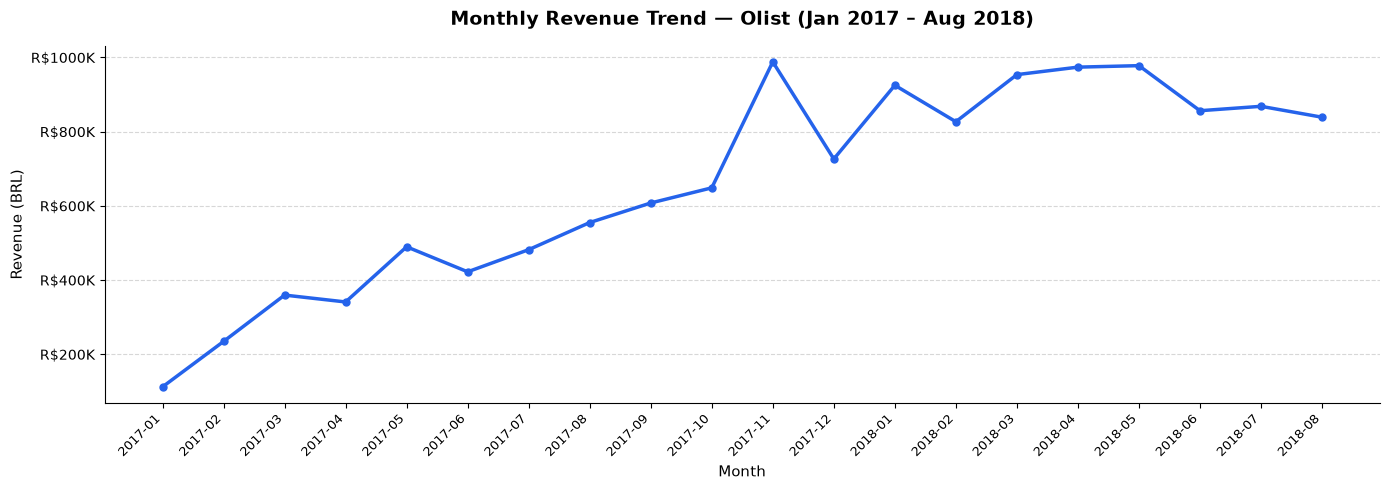

In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(range(len(revenue_trend)),
        revenue_trend['revenue'],
        color='#2563EB', linewidth=2.5, marker='o', markersize=5)

ax.set_xticks(range(len(revenue_trend)))
ax.set_xticklabels(revenue_trend['order_month'].astype(str),
                   rotation=45, ha='right', fontsize=9)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K'))

ax.set_title('Monthly Revenue Trend — Olist (Jan 2017 – Aug 2018)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue (BRL)', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

#### Revenue Trend

Revenue shows a strong upward trend throughout 2017, indicating rapid growth in Olist's marketplace. Revenue peaks in November 2017 at approximately R$988K, likely driven by Black Friday promotions. Although revenue falls in December, it remains well above earlier 2017 levels, suggesting that the decline is seasonal rather than indicative of weakening business performance.

Why did December fall?

There are two competing hypotheses.

### Hypothesis 1 (most likely)

Customers bought Christmas gifts during Black Friday sales instead of waiting until December.

This is called **pulling demand forward**.

Imagine someone planned to buy a TV in December.

- Black Friday offered a 30% discount.

- They bought it in November instead.

- November revenue increases.

- December decreases.

- Total revenue over the two months may be similar.

### Hypothesis 2

Black Friday attracted new customers who continued buying afterwards.

If this were true, December would likely remain extremely high.

Since December dropped noticeably, the evidence leans more toward customers shifting the timing of purchases rather than a permanent increase in demand.

In [13]:
revenue_per_category = df.groupby('product_category_name_english')['revenue'].sum().reset_index()
print("Highest Revenue Generating Categories:")
display(revenue_per_category.sort_values(by='revenue', ascending=False).head(10))
print("Least Revenue Generating Categories:")
display(revenue_per_category.sort_values(by='revenue').head(10))

Highest Revenue Generating Categories:


,product_category_name_english,revenue
43,health_beauty,1233131.72
70,watches_gifts,1166176.98
7,bed_bath_table,1023434.76
65,sports_leisure,954852.55
15,computers_accessories,888724.61
39,furniture_decor,711927.69
49,housewares,615628.69
20,cool_stuff,610204.10
5,auto,578966.65
69,toys,471286.48


Least Revenue Generating Categories:


,product_category_name_english,revenue
61,security_and_services,283.29
29,fashion_childrens_clothes,519.95
11,cds_dvds_musicals,730.00
46,home_comfort_2,760.27
35,flowers,1110.04
23,diapers_and_hygiene,1500.79
3,arts_and_craftmanship,1814.01
52,la_cuisine,2054.99
32,fashion_sport,2094.52
27,fashio_female_clothing,2634.94


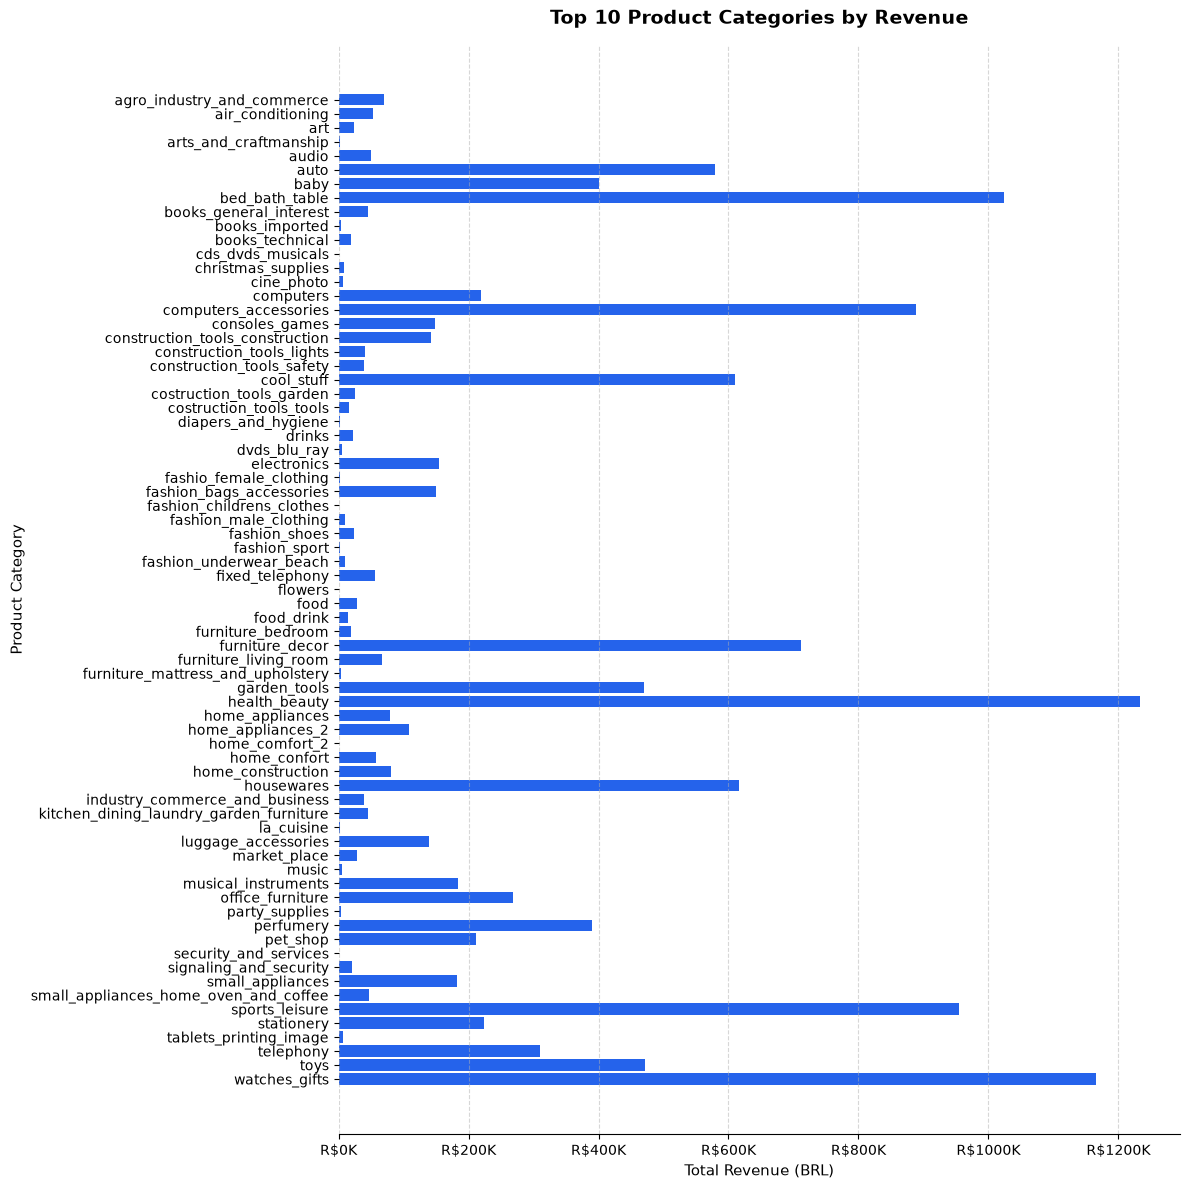

In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(12,12))

bars = ax.barh(
    revenue_per_category['product_category_name_english'],
    revenue_per_category['revenue'],
    color='#2563EB',
    edgecolor='none'
)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K')
)

ax.set_title(
    'Top 10 Product Categories by Revenue',
    fontsize=14,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Total Revenue (BRL)',
    fontsize=11
)

ax.set_ylabel(
    'Product Category',
    fontsize=11
)

# Highest value appears first
ax.invert_yaxis()

# Remove unnecessary borders
ax.spines[['top','right','left']].set_visible(False)

# Only horizontal value guides
ax.grid(axis='x',
        linestyle='--',
        alpha=0.5)

plt.tight_layout()

plt.savefig(
    '../reports/category_revenue.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

#### Product Categories

Revenue is concentrated in a relatively small number of product categories. Health Beauty, Watches & Gifts, and Bed Bath Table collectively account for a substantial share of total revenue. These categories represent Olist's strongest commercial segments and should remain priorities for inventory planning, supplier acquisition, and marketing investment.

In [15]:
revenue_per_state = df.groupby('customer_state')['revenue'].sum().reset_index()
display(revenue_per_state.sort_values(by='revenue', ascending=False).head(10))


,customer_state,revenue
25,SP,5067633.16
18,RJ,1759651.13
10,MG,1552481.83
22,RS,728897.47
17,PR,666063.51
23,SC,507012.13
4,BA,493584.14
6,DF,296498.41
8,GO,282836.70
7,ES,268643.45


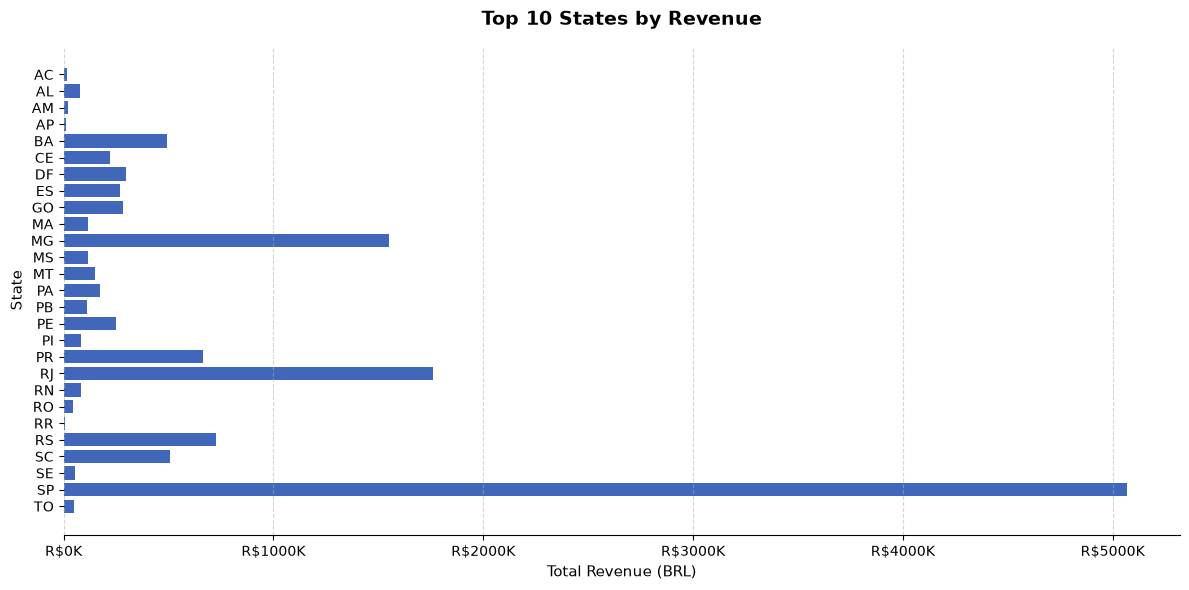

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(12,6))

bars = ax.barh(
    revenue_per_state['customer_state'],
    revenue_per_state['revenue'],
    color="#4067BA",
    edgecolor='none'
)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K')
)

ax.set_title(
    'Top 10 States by Revenue',
    fontsize=14,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Total Revenue (BRL)',
    fontsize=11
)

ax.set_ylabel(
    'State',
    fontsize=11
)

ax.invert_yaxis()

ax.spines[['top','right','left']].set_visible(False)

ax.grid(axis='x',
        linestyle='--',
        alpha=0.5)

plt.tight_layout()

plt.savefig(
    '../reports/state_revenue.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

#### Geographic Analysis

São Paulo (SP) is by far Olist's largest revenue-generating market, significantly outperforming every other state. While this demonstrates strong market penetration, it also indicates geographic concentration risk. Expanding successfully in other large states could diversify revenue and reduce dependence on a single region.

### Revenue Analysis — Executive Summary

**Prepared for:** Priya Mehta, Head of Analytics  
**Prepared by:** Noor Saba  
**Date:** *July 2026*

---

#### Overall Trend

The analysis shows that Olist experienced strong and consistent revenue growth throughout 2017 and into 2018. After excluding incomplete 2016 data, monthly revenue increased steadily from approximately **R$112K in January 2017** to a peak of **R$988K in November 2017**. Although monthly revenue fluctuated during 2018, it remained significantly higher than early 2017 levels, indicating that the business successfully maintained most of its growth momentum.

---

#### Peak and Seasonal Effects

Revenue reached its highest point in **November 2017**, most likely due to Brazil's **Black Friday** shopping event. The decline to approximately **R$726K in December 2017** suggests that many customers made holiday purchases earlier to take advantage of promotional discounts rather than waiting until December. This pattern indicates a seasonal shift in purchasing behavior rather than a decline in overall customer demand.

---

#### Product Category Performance

Revenue is concentrated within a relatively small number of product categories. **Health Beauty**, **Watches Gifts**, and **Bed Bath Table** generated the highest total revenue across the marketplace, making them Olist's strongest commercial segments. These categories should remain strategic priorities for supplier partnerships, inventory planning, and targeted marketing campaigns, while lower-performing categories may require further evaluation to identify growth opportunities.

---

#### Geographic Concentration

The analysis shows a strong geographic concentration of revenue in **São Paulo (SP)**, which generated substantially more revenue than any other Brazilian state. While this demonstrates Olist's strong market presence in the country's largest economy, it also creates business risk by increasing dependence on a single region. Expanding customer acquisition and seller participation in other major states such as **Rio de Janeiro (RJ)** and **Minas Gerais (MG)** would help diversify revenue and strengthen long-term business resilience.

---

#### Key Business Recommendations

Based on the findings of this analysis, the following actions are recommended:

- Continue investing in major promotional events such as **Black Friday**, as they have a significant positive impact on revenue generation.
- Prioritize high-performing product categories by strengthening supplier relationships and ensuring adequate inventory during peak shopping periods.
- Expand marketing and operational efforts in high-potential states outside São Paulo to reduce geographic concentration risk.
- Conduct further analysis on customer purchasing behavior before and after Black Friday to determine whether promotional campaigns create genuinely new demand or primarily shift purchases from December into November.

In [17]:
# Step 1: Filter to November and December 2017 only
nov_dec = df[
    df['order_month'].isin([
        pd.Period('2017-11'),
        pd.Period('2017-12')
    ])
].copy()

# Step 2: Group by category AND month — this gives revenue per category per month
nov_dec_grouped = (nov_dec
                   .groupby(['product_category_name_english', 'order_month'])['revenue']
                   .sum()
                   .reset_index()
                   .sort_values(by=['revenue'], ascending=[False])
                   )

# Step 3: Create a Pivot Table with categories as rows, months as columns, and revenue as values
nov_dec_pivot = nov_dec_grouped.pivot(index='product_category_name_english', columns='order_month', values='revenue').reset_index()

# Step 4: Rename columns cleanly
nov_dec_pivot.columns = ['category', 'nov_2017', 'dec_2017']


# Step 5: Fill any NaN with 0 
# (some categories may have sold in one month but not the other)
nov_dec_pivot = nov_dec_pivot.fillna(0)

# Step 6: Calculate the difference — positive means November was bigger
nov_dec_pivot['nov_vs_dec'] = nov_dec_pivot['nov_2017'] - nov_dec_pivot['dec_2017']

# Step 7: Sort by November revenue to see the biggest Black Friday categories
nov_dec_pivot = nov_dec_pivot.sort_values('nov_2017', ascending=False)

display(nov_dec_pivot.head(15))



,category,nov_2017,dec_2017,nov_vs_dec
65,watches_gifts,95292.34,69556.92,25735.42
6,bed_bath_table,87957.63,50081.16,37876.47
41,health_beauty,78274.40,60688.75,17585.65
14,computers_accessories,69676.32,37428.67,32247.65
60,sports_leisure,62686.24,58722.48,3963.76
64,toys,62611.26,55064.56,7546.70
37,furniture_decor,62091.27,31073.09,31018.18
19,cool_stuff,55696.66,37515.57,18181.09
40,garden_tools,44275.18,26795.69,17479.49
4,auto,34736.49,39019.96,-4283.47


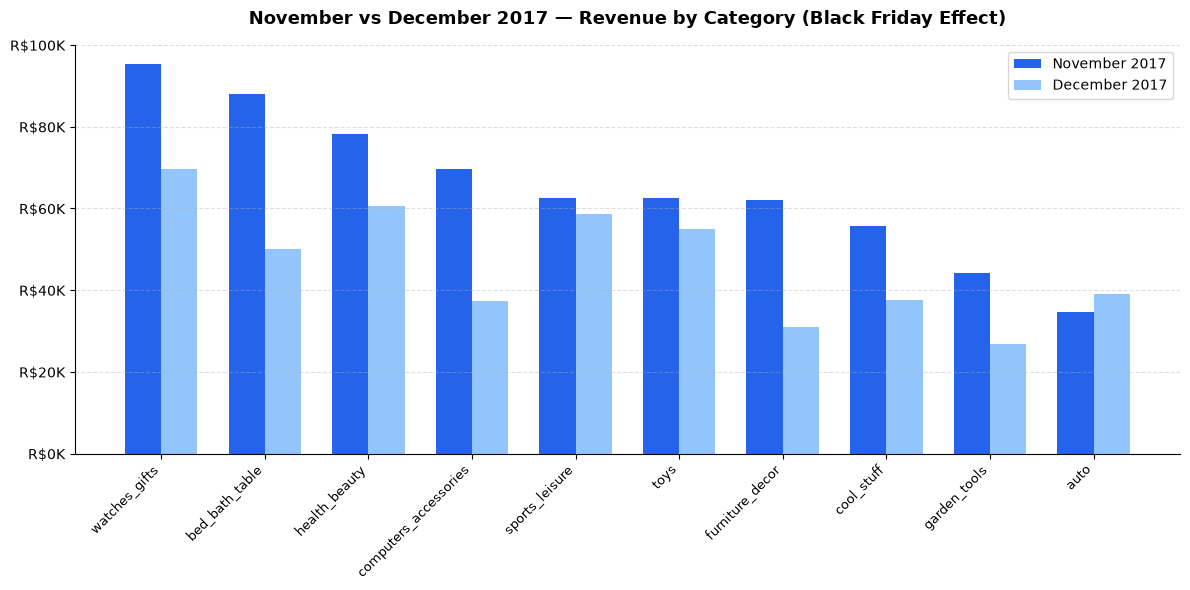

In [18]:
top_nov = nov_dec_pivot.head(10).set_index('category')

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(top_nov))
width = 0.35

ax.bar([i - width/2 for i in x], top_nov['nov_2017'], 
       width=width, label='November 2017', color='#2563EB')
ax.bar([i + width/2 for i in x], top_nov['dec_2017'], 
       width=width, label='December 2017', color='#93C5FD')

ax.set_xticks(x)
ax.set_xticklabels(top_nov.index, rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K'))
ax.set_title('November vs December 2017 — Revenue by Category (Black Friday Effect)',
             fontsize=13, fontweight='bold', pad=15)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../reports/nov_dec_category_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#### Black Friday Category Analysis

The November versus December comparison reveals two distinct 
category behaviours.

**High Black Friday sensitivity:** Watches & Gifts, 
Computers & Accessories, Furniture & Decor, and Bed Bath Table 
all showed significant November spikes followed by sharp December 
declines. These categories are price-sensitive and gift-oriented, 
making them natural candidates for Black Friday promotional 
investment in future years.

**Black Friday resistant:** The Auto category was the only 
segment where December revenue exceeded November, suggesting 
demand driven by need rather than opportunity. Promotional 
spend on this category during Black Friday events is unlikely 
to generate incremental revenue and should be reconsidered.

**Recommendation:** Concentrate Black Friday promotional 
budgets on the top 5 spike categories. Reallocate any 
automotive promotional spend to higher-sensitivity categories.